In [194]:
from collections import deque
import bisect
from pathlib import Path
import numpy as np

In [195]:
def calc_mu_sigma(k, e, vs):
    mu = (k-vs)*e + vs*(1-e)
    sigma = k*e*(1-e)
    return mu, sigma

def is_out_of_range(y, x, N):
    return not ((0 <= x < N) and (0 <= y < N))

def get_div_arr(n):
    d =  (n-1) // 4 + 1
    r = 4 * d - n
    ret = [4] * (d-r)
    ret += [3] * r
    sum_ret = [0]
    for i in range(len(ret)):
        sum_ret.append(sum_ret[i] + ret[i])
    return sum_ret

def print_grid_from_coordinates(coordinates):
    x_list = []
    y_list = []
    for coordinate in coordinates:
        y, x = coordinate
        x_list.append(x)
        y_list.append(y)
    x_max = max(x_list)
    y_max = max(y_list)
    disp_grid = [["." for _ in range(x_max+1)] for _ in range(y_max+1)]
    for coordinate in coordinates:
        ty, tx = coordinate
        disp_grid[ty][tx] = "#"
    for line in disp_grid:
        print("".join(line))

def print_grid_from_map(g):
    for l in g:
        print(" ".join(map(str, l)))

In [196]:
class Env:

    def __init__(self, file_path):
        with open(file_path, mode="r") as f:
            lines = f.readlines()
            N, M, ESP = lines[0].split()
            N, M, ESP = int(N), int(M), float(ESP)
            GRID = []
            lines = lines[1:]
            for _line in lines[:M]:
                _line = _line.split()
                ps = []
                for i in range(int(_line[0])):
                    ps.append((int(_line[2 * i + 1]), int(_line[2 * i + 2])))
                GRID.append(ps)
            lines = lines[2*M:]
            ANS_GRID = []
            for _line in lines[:N]:
                ANS_GRID.append(list(map(int, _line.split())))
        
        self.N = N
        self.M = M
        self.esp = ESP
        self.grids = GRID
        self.ans_grid = ANS_GRID

        self.total_size = sum(len(g) for g in self.grids)
        self._score = 0
        self.score = 10 ** 9

        cnt = 0
        for x in range(N):
            for y in range(N):
                if self.ans_grid[y][x] > 0:
                    cnt += 1
        self.ans_point_size = cnt
    
    def query1(self, coordinate):
        y, x = coordinate
        self._score += 1
        return self.ans_grid[y][x]

    def query2(self, coordinates):
        k = len(coordinates)
        vs = sum(self.ans_grid[y][x] for y, x in coordinates)
        mu, sigma = calc_mu_sigma(k, self.esp, vs)
        rng = np.random.default_rng()
        r = rng.normal(mu, sigma)
        self._score += 1 / np.sqrt(k)
        return max(0, round(r))

    def answer(self, coordinates):
        is_ok = self.total_size == sum(self.ans_grid[y][x] for y, x in coordinates)
        if is_ok:
            self.score = self._score
        else:
            self._score += 1
        return is_ok

In [197]:
from dataclasses import dataclass, field

@dataclass
class DivMap:
    query_num: int
    N: int
    n: int
    up: int
    left: int
    bottom:int
    right:int
    searched_num:int = 0
    searched_total:int = 0
    searched_points:set = field(default_factory=set)
    not_searched_points: set = field(default_factory=set)

    def evaluate(self):
        if (self.n-self.searched_num) == 0:
            return -10**9
        return (self.query_num - self.searched_total) / (self.n-self.searched_num)

    def query(self, coordinate, resp):
        self.searched_num += 1
        self.searched_total += resp
        self.searched_points.add(tuple(coordinate))
    
    def get_next_point(self):
        d_min = 10 ** 9
        ret = None
        for p in self.not_searched_points:
            y, x = p
            d = max(abs(0-y), (self.N-1-y)) + max(abs(0-x), (self.N-1-x))
            if d < d_min:
                d_min = d
                ret = p
        self.not_searched_points.remove(ret)
        return ret

In [198]:
class ResponseSimulator:

    def __init__(self, n: int, esp: float):
        self.esp = esp
        self.n = n

    def calc_best_query_num(self):
        INF = 10**9

        best_cost = INF
        best_q = 1
        for q in range(1, 15):
            cost = self.inference_score(q)
            if cost < best_cost:
                best_q = q
                best_cost = cost
        return best_q, best_cost
            
    def inference_correct_prob(self, query_num):

        mus = []
        for vs in range(201):
            mu, sigma = calc_mu_sigma(query_num, self.esp, vs)
            mus.append(mu)

        mu_mids = []
        for i in range(len(mus)-1):
            mu_mids.append((mus[i] + mus[i+1]) / 2)

        SAMPLE_N = 10 ** 5
        model_vs = query_num # 代表正解値。なんでもよいはず。

        mu, sigma = calc_mu_sigma(query_num, self.esp, model_vs)
        rng = np.random.default_rng()
        samples = rng.normal(mu, sigma, SAMPLE_N)

        correct_cnt = 0
        for sample in samples:
            if model_vs == bisect.bisect_left(mu_mids, max(0, round(sample))):
                correct_cnt += 1
        prob = correct_cnt / SAMPLE_N
        return prob

    def inference_score(self, query_num:int):
        if query_num == 1:
            return self.n**2
        grid_size = self.n**2
        prob = self.inference_correct_prob(query_num) ** grid_size
        # print(prob, self.esp, query_num)
        expected_cost = (grid_size / np.sqrt(query_num)) + grid_size * (1-prob)
        return expected_cost
    
    def env_setting(self, query_num: int):
        mus = []
        for vs in range(201):
            mu, sigma = calc_mu_sigma(query_num, self.esp, vs)
            mus.append(mu)

        mu_mids = []
        for i in range(len(mus)-1):
            mu_mids.append((mus[i] + mus[i+1]) / 2)

        self.query_num = query_num
        self.mu_mids = mu_mids

    def calc_true_val_from_response(self, resp_val):
        return bisect.bisect_left(self.mu_mids, resp_val)

In [199]:
class DivMapSolver():

    TH_CONTINUE = 0.3

    def __init__(self, env:Env):
        self.env = env
        ind_arrs = get_div_arr(env.N)
        div_maps = []

        response_simulator = ResponseSimulator(env.N, env.esp)
        for up, bottom in zip(ind_arrs[:-1], ind_arrs[1:]):
            for left, right in zip(ind_arrs[:-1], ind_arrs[1:]):
                points = set()
                n=(right-left) * (bottom-up)
                for x in range(right-left):
                    for y in range(bottom-up):
                        points.add((up+y, left+x))
                response_simulator.env_setting(n)
                query_num = response_simulator.calc_true_val_from_response(env.query2(points))
                div_map = DivMap(
                    N=env.N,
                    query_num=query_num,
                    n=n,
                    up=up,
                    bottom=bottom,
                    left=left,
                    right=right,
                    not_searched_points=points,
                )
                div_maps.append(div_map)
    
        self.div_maps = div_maps
        self.total_size = 0
        self.ans = []

        self.querys = []

    def _get_next_point(self):
        INF = 10**9
        max_val = -INF
        max_div = None
        for d in range(len(self.div_maps)):
            v = self.div_maps[d].evaluate()
            if v > max_val:
                max_val = v
                max_div = d
        self.max_div = max_div
        return self.div_maps[max_div].get_next_point()

    def _judge_continue(self):
        max_v = max(self.div_maps[d].evaluate() for d in range(len(self.div_maps)))
        if max_v <= DivMapSolver.TH_CONTINUE:
            return False
        return True
    
    def _query(self, coordinate):
        resp = self.env.query1(coordinate)
        self.total_size += resp
        if resp > 0:
            self.ans.append(coordinate)
        self.div_maps[self.max_div].query(coordinate, resp)
        self.querys.append((coordinate, resp))
    
    def solve(self):
        for _ in range(500):
            if self.env.total_size == self.total_size:
                self.env.answer(self.ans)
                return True
            if not self._judge_continue():
                return False
            coordinate = self._get_next_point()
            self._query(coordinate)
        raise ValueError()

In [200]:
class BFSSolver:
    """
        幅優先探索で貪欲的に確定する
        RESULT: 127.69
    """

    def __init__(self, N, total_oil_num):
        self.N = N
        self.grid_count = [[-1 for _ in range(N)] for _ in range(N)]
        self.grid_response = [[False for _ in range(N)] for _ in range(N)]
        self.grid_distance = [[0 for _ in range(N)] for _ in range(N)]
        for x in range(N):
            for y in range(N):
                self.grid_distance[y][x] = min(x + 1, y + 1, N - x, N - y)

        self.total_count = 0
        self.total_oil_nums = total_oil_num

        self.next_grids = set()

    def is_ok(self):
        return self.total_count == self.total_oil_nums

    def get_plus_grids(self):
        ret = []
        for x in range(self.N):
            for y in range(self.N):
                if self.grid_count[y][x] == -1:
                    continue
                if self.grid_count[y][x] > 0:
                    ret.append((y, x))
        return ret

    def response(self, y, x, val):
        self.grid_count[y][x] = val
        self.grid_response[y][x] = True
        if val > 0:
            self.total_count += val
            for dy, dx in [[0, 1], [1, 0], [0, -1], [-1, 0]]:
                ny, nx = y + dy, x + dx
                if not (0 <= nx < self.N and 0 <= ny < self.N):
                    continue
                if not self.grid_response[ny][nx]:
                    self.next_grids.add((ny, nx))
        self._update_distance(y, x)

    def get_next_search_point(self):
        while self.next_grids:
            y, x = self.next_grids.pop()
            if not self.grid_response[y][x]:
                return y, x

        return self._get_far_point_from_wall()

    def _update_distance(self, y, x):
        searched = [[False for _ in range(self.N)] for _ in range(self.N)]
        self.grid_distance[y][x] = 0
        start = [(y, x)]
        search_q = deque(start)
        while search_q:
            py, px = search_q.popleft()
            searched[py][px] = True
            if searched[py][px]:
                continue
            for dy, dx in [[0, 1], [1, 0], [0, -1], [-1, 0]]:
                ny, nx = py + dy, px + dx
                if not (0 <= nx < self.N and 0 <= ny < self.N):
                    continue
                if self.grid_distance[ny][nx] == 0 or searched[ny][nx]:
                    continue
                search_q.append((ny, nx))
                self.grid_distance[ny][nx] = min(
                    self.grid_distance[ny][nx], self.grid_distance[py][px] + 1
                )

    def _get_far_point_from_wall(self):
        max_val = -10**9
        ret = None
        for x in range(self.N):
            for y in range(self.N):
                if self.grid_response[y][x]:
                    continue
                if self.grid_distance[y][x] > max_val:
                    max_val = self.grid_distance[y][x]
                    ret = y, x
        if ret is None:
            raise NotImplementedError("Why?")
        return ret

# Solve

In [201]:
import random

scores = []
n_size = []
ans_points = []

def main():
    random.seed(0)
    for test_num in range(100):
        try:
            env = Env(file_path = Path(f"./in/{test_num:0>4}.txt"))
            n_size.append(env.N**2)
            ans_points.append(env.ans_point_size)
            if env.esp <= 0.02:
                div_map_solver = DivMapSolver(env=env)
                if not div_map_solver.solve():
                    bfs_solver = BFSSolver(env.N, total_oil_num=env.total_size)
                    if div_map_solver.querys is not None:
                        for coordinate, resp in div_map_solver.querys:
                            y, x = coordinate
                            bfs_solver.response(y, x, resp)
                    for i in range(100000):
                        # print(bfs_solver.total_count, env.total_size)
                        if bfs_solver.is_ok():
                            env.answer(bfs_solver.get_plus_grids())
                            break
                        y, x = bfs_solver.get_next_search_point()
                        v = env.query1((y, x))
                        bfs_solver.response(y, x, v)
            else:
                bfs_solver = BFSSolver(env.N, total_oil_num=env.total_size)
                for i in range(100000):
                    y, x = bfs_solver.get_next_search_point()
                    v = env.query1((y, x))
                    bfs_solver.response(y, x, v)
                    if bfs_solver.is_ok():
                        env.answer(bfs_solver.get_plus_grids())
                        break
            scores.append(env.score)
        except Exception as e:
            print(test_num, e)
            scores.append(10**9)
main()

# Evaluate

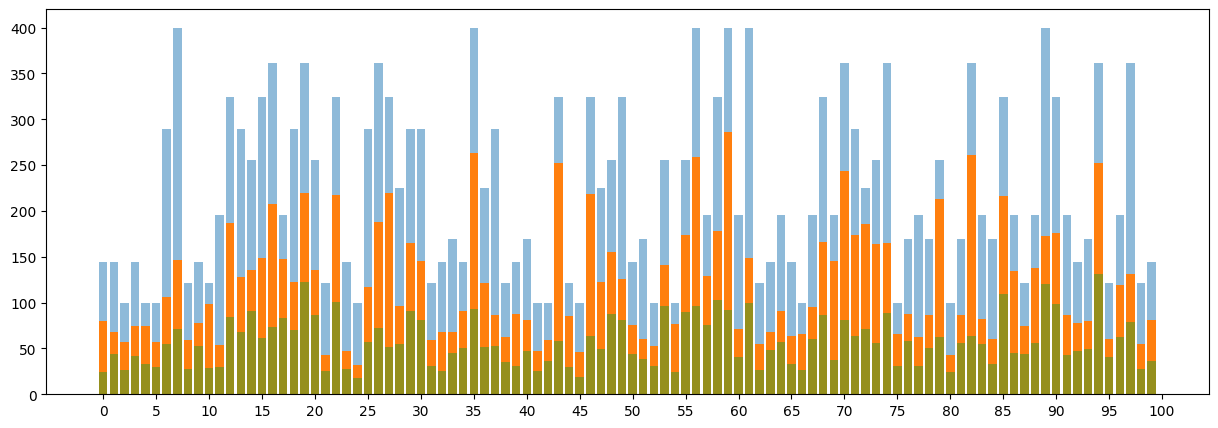

119.9643375672974


In [202]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))
plt.bar(list(range(len(n_size))), n_size, alpha=0.5)
plt.bar(list(range(len(scores))), scores)
plt.bar(list(range(len(ans_points))), ans_points, alpha=0.5)

plt.xticks(range(0, len(scores)+1, 5))
plt.show()

print(sum(scores) / len(scores))